In [ ]:
# OASIS Infobyte - Data Science Internship
# Task 1: Iris Flower Classification

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Basic information about the dataset

print("Shape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNull values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

Shape of dataset: (150, 5)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Null values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
# Convert species numbers into actual species names

df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


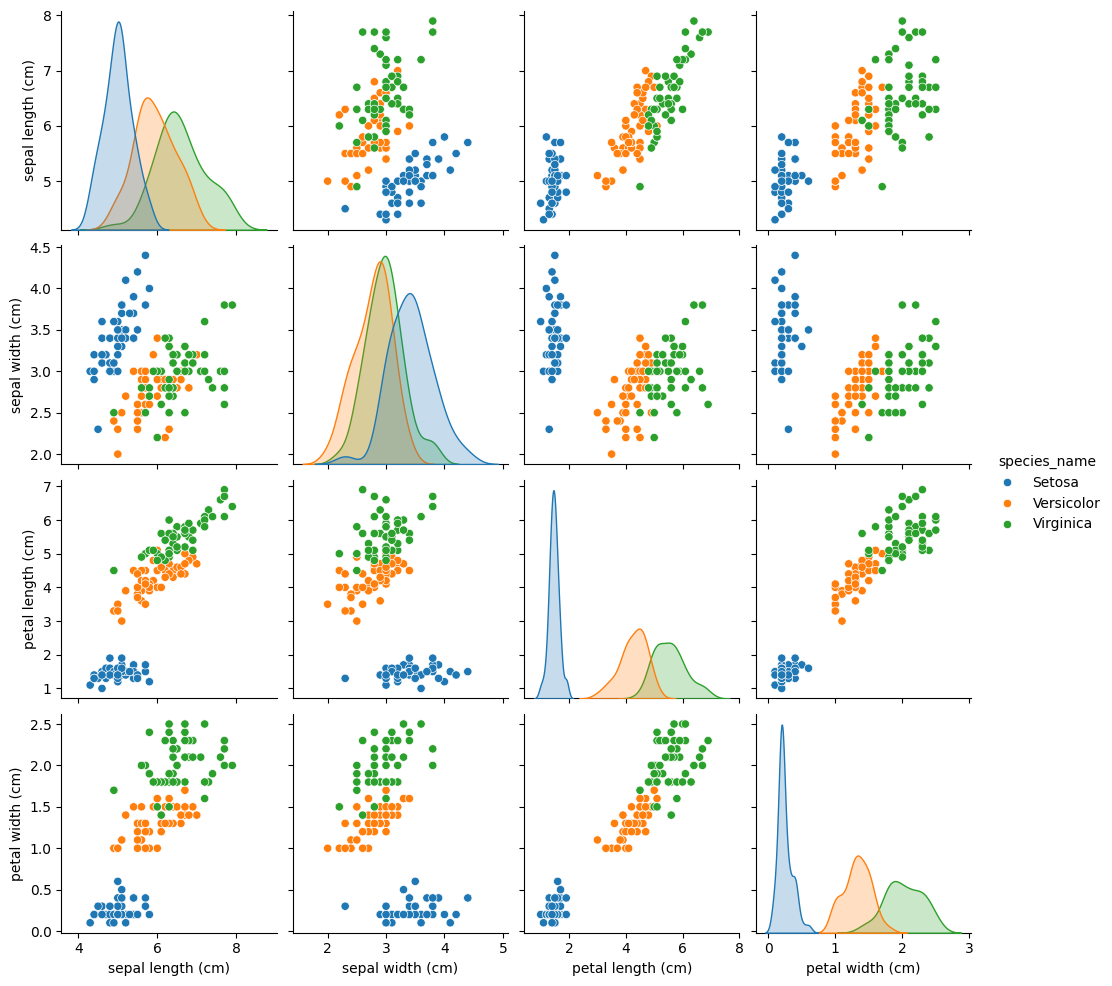

In [ ]:
# Pairplot: relationship between all features by species

sns.pairplot(
    df,
    hue="species_name",
    vars=iris.feature_names
)

plt.show()

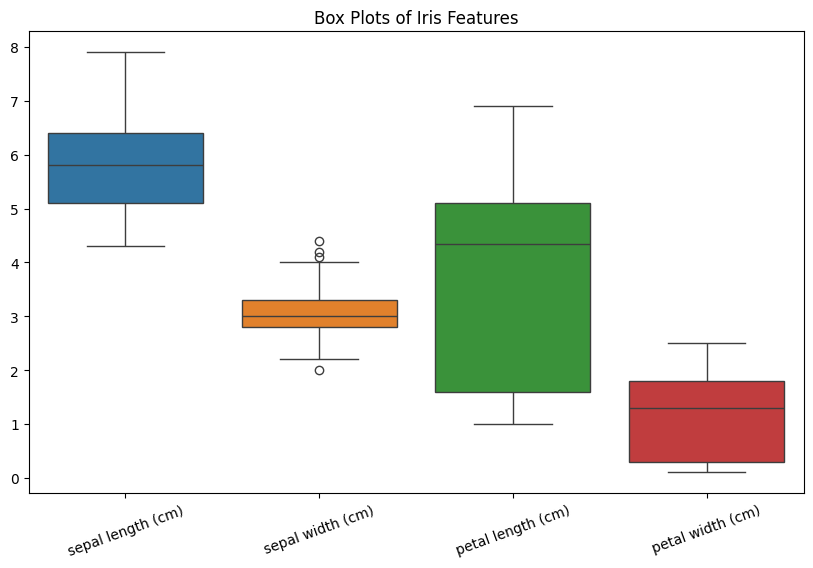

In [ ]:
# Box plots for all Iris features

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[iris.feature_names]
)

plt.title("Box Plots of Iris Features")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# Feature selection discussion

print("Feature Selection:")
print()
print("Petal length and petal width are the most discriminative features")
print("because they show clearer separation between the three Iris species.")
print()
print("Sepal length and sepal width are useful, but their values overlap")
print("more between some species.")

Feature Selection:

Petal length and petal width are the most discriminative features
because they show clearer separation between the three Iris species.

Sepal length and sepal width are useful, but their values overlap
more between some species.


In [ ]:
# Separate features (X) and target (y)

X = df[iris.feature_names]
y = df["species"]

# Split the data into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [ ]:
# Classifier 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create and train the model
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [3]:
# Task 1: Prepare data and train the second classifier (KNN)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load Iris dataset
iris = load_iris()

# Prepare features and target
X = iris.data
y = iris.target

# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("KNN model trained successfully.")

Training data: (120, 4)
Testing data: (30, 4)
KNN model trained successfully.


In [5]:
# Model Evaluation - Logistic Regression and KNN

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# Logistic Regression
# -------------------------------

logistic_model = LogisticRegression(max_iter=200)

# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


# -------------------------------
# K-Nearest Neighbors (KNN)
# -------------------------------

print("===== K-Nearest Neighbors (KNN) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

===== Logistic Regression =====
Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

===== K-Nearest Neighbors (KNN) =====
Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1

## Model Comparison and Best-Performing Model

Both Logistic Regression and K-Nearest Neighbors (KNN) achieved an accuracy of 100% on the test dataset.

Both models also produced perfect precision, recall, and F1-scores for all three Iris species.

Therefore, neither model outperformed the other based on the evaluation metrics. Both models performed equally well on this test set.

Logistic Regression is selected as the preferred model for this project because it is a simple and interpretable classification algorithm, while KNN also achieved the same predictive performance.

## Conclusion

The Iris Flower Classification project successfully classified the three Iris species: Setosa, Versicolor, and Virginica.

Exploratory data analysis helped understand the relationships between the flower features. Logistic Regression and K-Nearest Neighbors were trained and evaluated using accuracy, confusion matrices, and classification reports.

Both models achieved excellent performance on the test dataset, demonstrating that the Iris dataset can be effectively classified using machine learning techniques.

## Task 1 Completion Checklist

✓ Iris dataset loaded using sklearn.datasets.load_iris()
✓ Exploratory Data Analysis completed
✓ Dataset shape, data types, missing values, and descriptive statistics checked
✓ Pairplot / scatter matrix completed
✓ Box plots completed
✓ Feature selection discussed
✓ 80/20 train-test split completed
✓ Logistic Regression implemented
✓ K-Nearest Neighbors (KNN) implemented
✓ Accuracy calculated
✓ Confusion matrices generated
✓ Classification reports generated
✓ Models compared
✓ Best-performing model discussion completed
✓ Final conclusion added

### Task 1: Iris Flower Classification — COMPLETED